#### Project Brief — Sales Performance Analytics

- Business Context:
A retail company selling office supplies, furniture, and technology products across four U.S. regions has observed a notable shift in revenue this quarter compared to the same period last year. The sales leadership team needs to understand which products, regions, and customer segments are driving this change — and whether the shift reflects a structural trend or a temporary fluctuation.

- Decision to be made:
Determine the root cause of the quarterly revenue change and recommend whether to reallocate sales resources, adjust discounting strategy, or prioritize specific product categories.

- Success metric:
Identify the top 3 drivers of revenue change (positive or negative) with supporting data, and quantify the expected revenue impact of the recommended action.
- Stakeholder:
Head of Sales / Sales Director — needs a clear, visual explanation they can act on without digging into raw data.

In [1]:
# ============================================================
# Sales Performance EDA — Starter Code
# Dataset: Superstore Sales (~10,000 rows)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Style config ---
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [5]:
# ============================================================
# 1. LOAD DATA
# ============================================================

df_raw = pd.read_csv("superstore_sales.csv", encoding="latin-1")
df = df_raw.copy()  # Always keep a raw copy untouched

print("=" * 50)
print("DATASET LOADED")
print("=" * 50)
print(f"Shape     : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory    : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print()
print(df.head(3).to_string())

DATASET LOADED
Shape     : 9,994 rows × 21 columns
Memory    : 10617.8 KB

   Row ID        Order ID  Order Date   Ship Date     Ship Mode Customer ID    Customer Name    Segment        Country         City       State  Postal Code Region       Product ID         Category Sub-Category                                                 Product Name   Sales  Quantity  Discount    Profit
0       1  CA-2013-152156  09-11-2013  12-11-2013  Second Class    CG-12520      Claire Gute   Consumer  United States    Henderson    Kentucky        42420  South  FUR-BO-10001798        Furniture    Bookcases                            Bush Somerset Collection Bookcase  261.96         2       0.0   41.9136
1       2  CA-2013-152156  09-11-2013  12-11-2013  Second Class    CG-12520      Claire Gute   Consumer  United States    Henderson    Kentucky        42420  South  FUR-CH-10000454        Furniture       Chairs  Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back  731.94         3       0.0  219.

In [8]:
# ============================================================
# 2. DATA TYPES & SCHEMA
# ============================================================

print("\n" + "=" * 50)
print("SCHEMA & DATA TYPES")
print("=" * 50)
print(df.dtypes)

# Fix date columns (often read as object/string)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=False, format='%d-%m-%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=False, format='%d-%m-%Y')

# Verify numeric columns
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
print("\nNumeric column stats:")
print(df[numeric_cols].describe().round(2))



SCHEMA & DATA TYPES
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Numeric column stats:
          Sales  Quantity  Discount   Profit
count   9994.00   9994.00   9994.00  9994.00
mean     229.86      3.79      0.16    28.66
std      623.25      2.23      0.21   234.26
min        0.44      1.00      0.00 -6599.98
25%       17.28      2.00      0.00     1.73
50%       54.49      3.00      0.20     8.67
75%      209.94      5.00      0.20    29.36
max    22638.48     14.00      0.80  8399.98


In [9]:
# ============================================================
# 3. MISSING VALUES
# ============================================================

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')

if missing_df.empty:
    print("No missing values found.")
else:
    print(missing_df)
    # Decision: document your strategy here
    # e.g. df['Profit'].fillna(df['Profit'].median(), inplace=True)



MISSING VALUES
No missing values found.


In [10]:
# ============================================================
# 4. DUPLICATES
# ============================================================

print("\n" + "=" * 50)
print("DUPLICATES")
print("=" * 50)

full_dupes = df.duplicated().sum()
order_dupes = df.duplicated(subset=['Order ID', 'Product Name']).sum()

print(f"Full row duplicates         : {full_dupes}")
print(f"Duplicate Order+Product rows: {order_dupes}")

# Drop full duplicates if any
if full_dupes > 0:
    df = df.drop_duplicates()
    print(f"  → Dropped {full_dupes} duplicate rows. New shape: {df.shape}")


DUPLICATES
Full row duplicates         : 0
Duplicate Order+Product rows: 13


In [11]:
# ============================================================
# 5. OUTLIER CHECK
# ============================================================

print("\n" + "=" * 50)
print("OUTLIER CHECK (IQR method)")
print("=" * 50)

for col in ['Sales', 'Profit']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:10s} | Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f} | Outliers: {n_outliers}")

# Note: Outliers in Sales/Profit are often VALID large orders — don't drop blindly



OUTLIER CHECK (IQR method)
Sales      | Q1=17  Q3=210  IQR=193 | Outliers: 1167
Profit     | Q1=2  Q3=29  IQR=28 | Outliers: 1881


In [12]:
# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

# Days to ship — useful for operations analysis
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

# Profit margin per order line
df['Profit Margin %'] = (df['Profit'] / df['Sales'].replace(0, np.nan) * 100).round(2)

# Quarter and Year for time-based grouping
df['Order Year']    = df['Order Date'].dt.year
df['Order Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)
df['Order Month']   = df['Order Date'].dt.to_period('M').astype(str)

print("\n" + "=" * 50)
print("ENGINEERED FEATURES ADDED")
print("=" * 50)
print(df[['Order Date', 'Ship Date', 'Days to Ship', 'Sales', 'Profit', 'Profit Margin %', 'Order Quarter']].head(5))



ENGINEERED FEATURES ADDED
  Order Date  Ship Date  Days to Ship     Sales    Profit  Profit Margin %  \
0 2013-11-09 2013-11-12             3  261.9600   41.9136            16.00   
1 2013-11-09 2013-11-12             3  731.9400  219.5820            30.00   
2 2013-06-13 2013-06-17             4   14.6200    6.8714            47.00   
3 2012-10-11 2012-10-18             7  957.5775 -383.0310           -40.00   
4 2012-10-11 2012-10-18             7   22.3680    2.5164            11.25   

  Order Quarter  
0        2013Q4  
1        2013Q4  
2        2013Q2  
3        2012Q4  
4        2012Q4  


In [13]:
# ============================================================
# 7. EDA SUMMARY
# ============================================================

print("\n" + "=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"Date range     : {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"Unique customers: {df['Customer ID'].nunique():,}")
print(f"Unique products : {df['Product Name'].nunique():,}")
print(f"Regions         : {df['Region'].unique().tolist()}")
print(f"Categories      : {df['Category'].unique().tolist()}")
print(f"Segments        : {df['Segment'].unique().tolist()}")
print(f"Total Revenue   : ${df['Sales'].sum():,.0f}")
print(f"Total Profit    : ${df['Profit'].sum():,.0f}")
print(f"Overall Margin  : {df['Profit'].sum() / df['Sales'].sum() * 100:.1f}%")


EDA SUMMARY
Date range     : 2011-01-04 → 2014-12-31
Unique customers: 793
Unique products : 1,841
Regions         : ['South', 'West', 'Central', 'East']
Categories      : ['Furniture', 'Office Supplies', 'Technology']
Segments        : ['Consumer', 'Corporate', 'Home Office']
Total Revenue   : $2,297,201
Total Profit    : $286,397
Overall Margin  : 12.5%


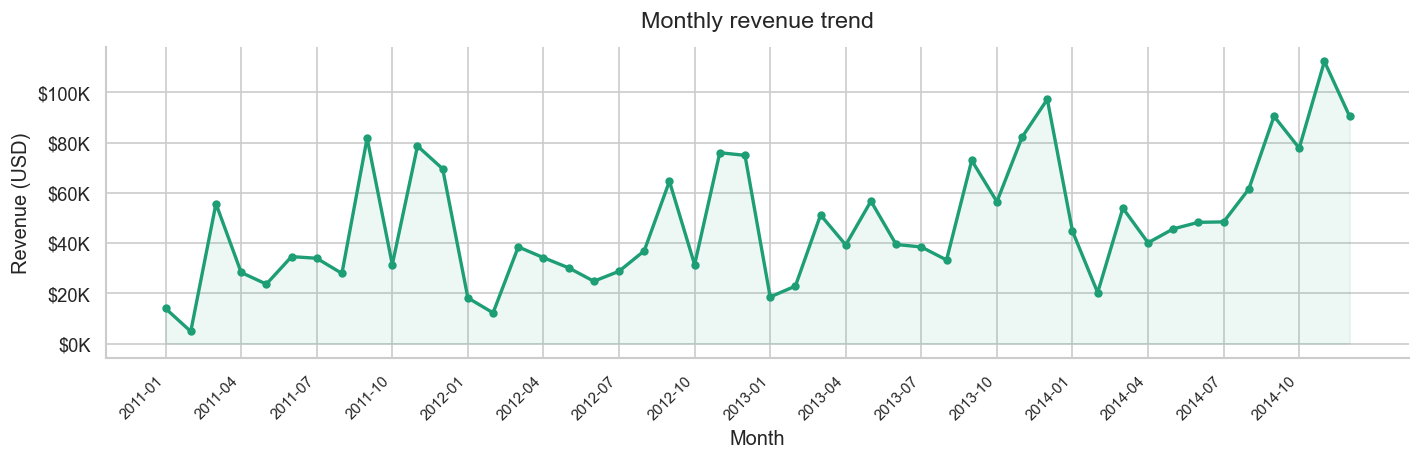

In [14]:
# ============================================================
# 8. VISUALIZATION 1 — Monthly Revenue Trend
# ============================================================

monthly = (
    df.groupby('Order Month')['Sales']
    .sum()
    .reset_index()
    .sort_values('Order Month')
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['Order Month'], monthly['Sales'], color='#1D9E75', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly['Order Month'], monthly['Sales'], alpha=0.08, color='#1D9E75')

# Rotate x-axis labels
ax.set_xticks(range(0, len(monthly), 3))
ax.set_xticklabels(monthly['Order Month'].iloc[::3], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

ax.set_title('Monthly revenue trend', fontsize=14, fontweight='medium', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (USD)')
plt.tight_layout()
plt.savefig('viz1_monthly_revenue.png', bbox_inches='tight')
plt.show()

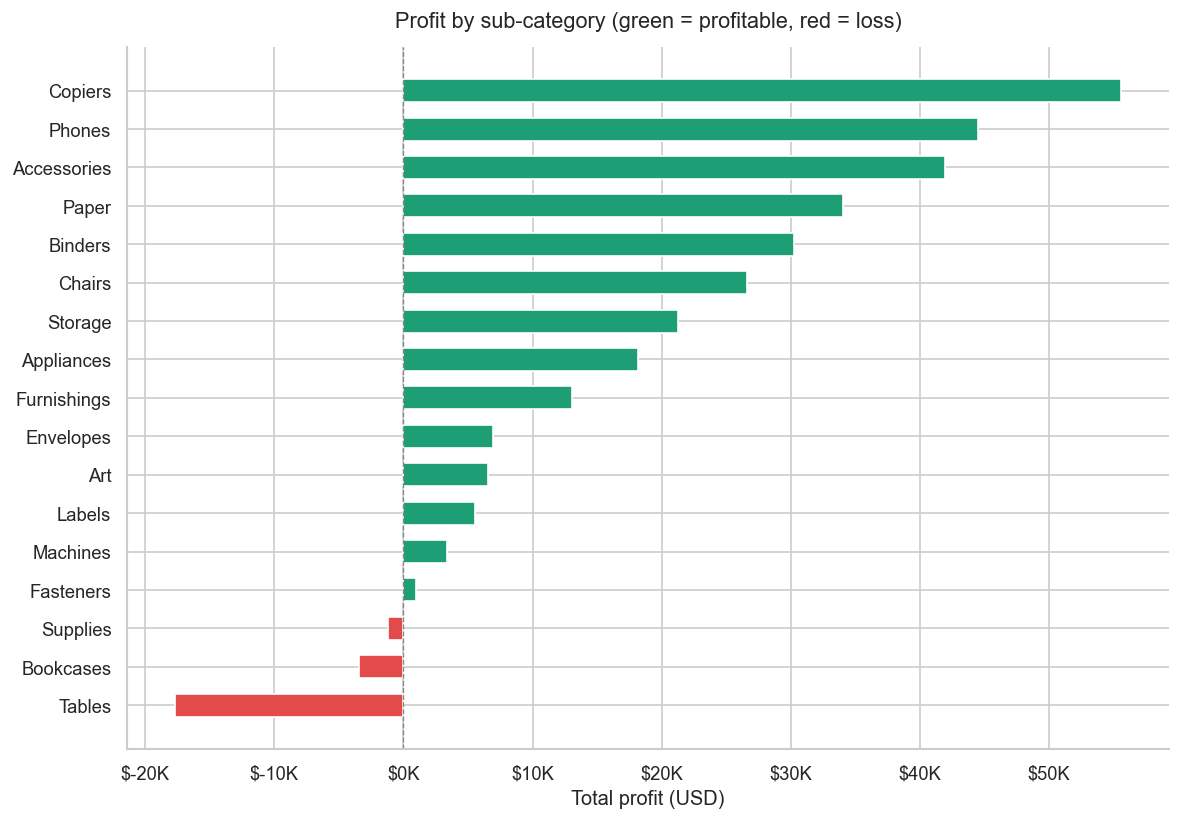

In [15]:
# ============================================================
# 9. VISUALIZATION 2 — Profit by Category & Sub-Category
# ============================================================

subcat_profit = (
    df.groupby(['Category', 'Sub-Category'])['Profit']
    .sum()
    .reset_index()
    .sort_values('Profit', ascending=True)
)

colors = subcat_profit['Profit'].apply(lambda x: '#E24B4A' if x < 0 else '#1D9E75')

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(subcat_profit['Sub-Category'], subcat_profit['Profit'], color=colors, height=0.6)
ax.axvline(0, color='#888780', linewidth=0.8, linestyle='--')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

ax.set_title('Profit by sub-category (green = profitable, red = loss)', fontsize=13, fontweight='medium', pad=12)
ax.set_xlabel('Total profit (USD)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('viz2_profit_by_subcat.png', bbox_inches='tight')
plt.show()

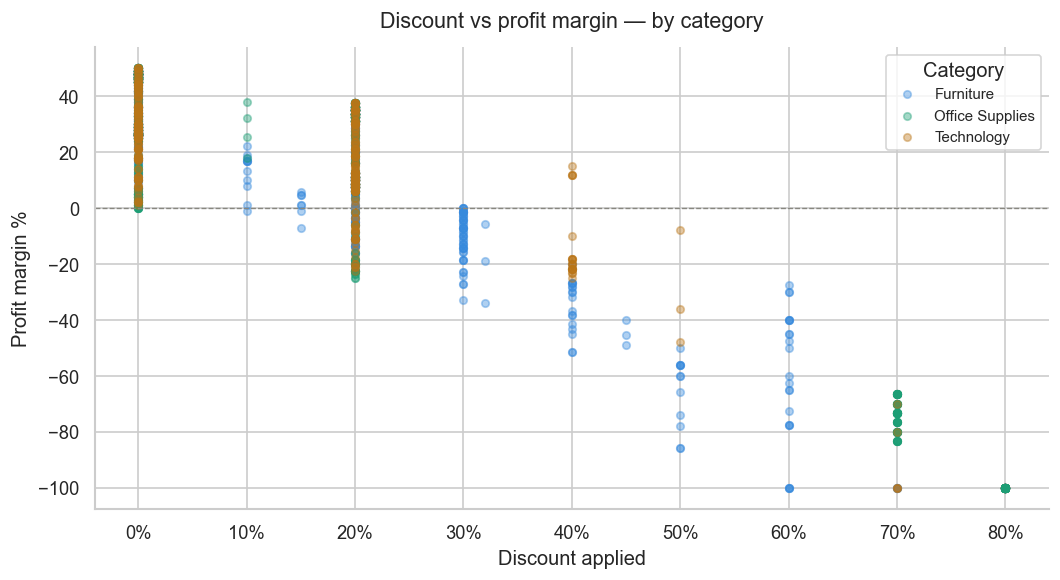


All visualizations saved as PNG files.


In [16]:
# ============================================================
# 10. VISUALIZATION 3 — Discount vs Profit Margin Scatter
# ============================================================

# Sample to avoid overplotting on large datasets
sample = df.sample(min(2000, len(df)), random_state=42)

category_colors = {'Furniture': '#378ADD', 'Office Supplies': '#1D9E75', 'Technology': '#BA7517'}
sample['Color'] = sample['Category'].map(category_colors)

fig, ax = plt.subplots(figsize=(9, 5))
for cat, grp in sample.groupby('Category'):
    ax.scatter(
        grp['Discount'],
        grp['Profit Margin %'].clip(-100, 100),  # clip extreme outliers for viz
        alpha=0.4,
        s=20,
        color=category_colors[cat],
        label=cat
    )

ax.axhline(0, color='#888780', linewidth=0.8, linestyle='--')
ax.set_xlabel('Discount applied')
ax.set_ylabel('Profit margin %')
ax.set_title('Discount vs profit margin — by category', fontsize=13, fontweight='medium', pad=12)
ax.legend(title='Category', fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.savefig('viz3_discount_vs_margin.png', bbox_inches='tight')
plt.show()

print("\nAll visualizations saved as PNG files.")

In [33]:
import duckdb
import pandas as pd

CSV_PATH = "superstore_sales.csv"
con = duckdb.connect()

# ✅ Definisi view sekali di awal — tulis encoding cukup di sini
con.execute(f"""
    CREATE OR REPLACE VIEW orders AS
    SELECT * FROM read_csv('{CSV_PATH}',
        encoding     = 'ISO_8859_1',
        auto_detect  = true,
        dateformat   = '%d-%m-%Y'   -- sesuaikan jika format tanggal berbeda
    )
""")

# Verifikasi berhasil
print(con.execute("SELECT COUNT(*) AS total_rows FROM orders").df())
print(con.execute("DESCRIBE orders").df())

   total_rows
0        9994
      column_name column_type null   key default extra
0          Row ID      BIGINT  YES  None    None  None
1        Order ID     VARCHAR  YES  None    None  None
2      Order Date        DATE  YES  None    None  None
3       Ship Date        DATE  YES  None    None  None
4       Ship Mode     VARCHAR  YES  None    None  None
5     Customer ID     VARCHAR  YES  None    None  None
6   Customer Name     VARCHAR  YES  None    None  None
7         Segment     VARCHAR  YES  None    None  None
8         Country     VARCHAR  YES  None    None  None
9            City     VARCHAR  YES  None    None  None
10          State     VARCHAR  YES  None    None  None
11    Postal Code     VARCHAR  YES  None    None  None
12         Region     VARCHAR  YES  None    None  None
13     Product ID     VARCHAR  YES  None    None  None
14       Category     VARCHAR  YES  None    None  None
15   Sub-Category     VARCHAR  YES  None    None  None
16   Product Name     VARCHAR  YES  N

In [26]:
# ============================================================
# Query 1 — Core KPIs
# ============================================================
kpi = con.execute("""
    SELECT
        ROUND(SUM(Sales), 0)                      AS total_revenue,
        ROUND(SUM(Profit), 0)                     AS total_profit,
        ROUND(SUM(Profit) / SUM(Sales) * 100, 1) AS profit_margin_pct,
        ROUND(AVG(Sales), 2)                      AS avg_order_line_value,
        COUNT(DISTINCT "Order ID")                AS total_orders,
        COUNT(DISTINCT "Customer ID")             AS total_customers
    FROM orders
""").df()
print("=== CORE KPIs ===")
print(kpi.to_string(index=False))

=== CORE KPIs ===
 total_revenue  total_profit  profit_margin_pct  avg_order_line_value  total_orders  total_customers
     2297201.0      286397.0               12.5                229.86          5009              793


In [27]:
# ============================================================
# Query 2 — Revenue & Profit by Region + Category
# ============================================================
region_cat = con.execute("""
    SELECT
        Region,
        Category,
        ROUND(SUM(Sales), 0)                      AS revenue,
        ROUND(SUM(Profit), 0)                     AS profit,
        ROUND(SUM(Profit) / SUM(Sales) * 100, 1) AS margin_pct,
        COUNT(DISTINCT "Order ID")                AS orders
    FROM orders
    GROUP BY Region, Category
    ORDER BY revenue DESC
""").df()
print("\n=== REVENUE & PROFIT BY REGION + CATEGORY ===")
print(region_cat.to_string(index=False))


=== REVENUE & PROFIT BY REGION + CATEGORY ===
 Region        Category  revenue  profit  margin_pct  orders
   East      Technology 264974.0 47462.0        17.9     443
   West       Furniture 252613.0 11505.0         4.6     595
   West      Technology 251992.0 44304.0        17.6     490
   West Office Supplies 220853.0 52610.0        23.8    1169
   East       Furniture 208291.0  3046.0         1.5     488
   East Office Supplies 205516.0 41015.0        20.0    1074
Central      Technology 170416.0 33697.0        19.8     356
Central Office Supplies 167026.0  8880.0         5.3     880
Central       Furniture 163797.0 -2871.0        -1.8     403
  South      Technology 148772.0 19992.0        13.4     255
  South Office Supplies 125651.0 19986.0        15.9     619
  South       Furniture 117299.0  6771.0         5.8     278


In [28]:
# ============================================================
# Query 3 — Top 10 & Bottom 10 Products by Profit
# ============================================================
top10 = con.execute("""
    SELECT
        "Product Name",
        Category,
        "Sub-Category",
        ROUND(SUM(Sales), 0)  AS revenue,
        ROUND(SUM(Profit), 0) AS profit,
        SUM(Quantity)         AS units_sold
    FROM orders
    GROUP BY "Product Name", Category, "Sub-Category"
    ORDER BY profit DESC
    LIMIT 10
""").df()

bottom10 = con.execute("""
    SELECT
        "Product Name",
        Category,
        "Sub-Category",
        ROUND(SUM(Sales), 0)  AS revenue,
        ROUND(SUM(Profit), 0) AS profit,
        SUM(Quantity)         AS units_sold
    FROM orders
    GROUP BY "Product Name", Category, "Sub-Category"
    ORDER BY profit ASC
    LIMIT 10
""").df()
print("\n=== TOP 10 PRODUCTS BY PROFIT ===")
print(top10.to_string(index=False))
print("\n=== BOTTOM 10 PRODUCTS (LOSS MAKERS) ===")
print(bottom10.to_string(index=False))


=== TOP 10 PRODUCTS BY PROFIT ===
                                                               Product Name        Category Sub-Category  revenue  profit  units_sold
                                      Canon imageCLASS 2200 Advanced Copier      Technology      Copiers  61600.0 25200.0        20.0
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind Office Supplies      Binders  27453.0  7753.0        31.0
                                       Hewlett Packard LaserJet 3310 Copier      Technology      Copiers  18840.0  6984.0        38.0
                                         Canon PC1060 Personal Laser Copier      Technology      Copiers  11620.0  4571.0        19.0
                  HP Designjet T520 Inkjet Large Format Printer - 24" Color      Technology     Machines  18375.0  4095.0        12.0
                                          Ativa V4110MDD Micro-Cut Shredder      Technology     Machines   7700.0  3773.0        11.0
                           

In [29]:
# ============================================================
# Query 4 — Quarterly Revenue Trend
# ============================================================
quarterly = con.execute("""
    SELECT
        YEAR("Order Date")                            AS year,
        QUARTER("Order Date")                         AS quarter,
        CONCAT(YEAR("Order Date"), '-Q',
               QUARTER("Order Date"))                 AS period,
        ROUND(SUM(Sales), 0)                          AS revenue,
        ROUND(SUM(Profit), 0)                         AS profit,
        ROUND(SUM(Profit) / SUM(Sales) * 100, 1)     AS margin_pct,
        COUNT(DISTINCT "Order ID")                    AS orders
    FROM orders
    GROUP BY 1, 2, 3
    ORDER BY 1, 2
""").df()
print("\n=== QUARTERLY REVENUE TREND ===")
print(quarterly.to_string(index=False))



=== QUARTERLY REVENUE TREND ===
 year  quarter  period  revenue  profit  margin_pct  orders
 2011        1 2011-Q1  74448.0  3811.0         5.1     131
 2011        2 2011-Q2  86539.0 11204.0        12.9     201
 2011        3 2011-Q3 143633.0 12805.0         8.9     267
 2011        4 2011-Q4 179628.0 21724.0        12.1     370
 2012        1 2012-Q1  68852.0  9265.0        13.5     144
 2012        2 2012-Q2  89124.0 12191.0        13.7     214
 2012        3 2012-Q3 130260.0 16854.0        12.9     274
 2012        4 2012-Q4 182297.0 23309.0        12.8     406
 2013        1 2013-Q1  92596.0 11446.0        12.4     177
 2013        2 2013-Q2 135370.0 16085.0        11.9     294
 2013        3 2013-Q3 144614.0 16154.0        11.2     378
 2013        4 2013-Q4 235893.0 38042.0        16.1     461
 2014        1 2014-Q1 118896.0 21772.0        18.3     237
 2014        2 2014-Q2 134023.0 17166.0        12.8     367
 2014        3 2014-Q3 200433.0 26913.0        13.4     451
 2014  

In [30]:
# ============================================================
# Query 5 — Quarter-over-Quarter Change
# ============================================================
qoq = con.execute("""
    WITH quarterly AS (
        SELECT
            CONCAT(YEAR("Order Date"), '-Q',
                   QUARTER("Order Date"))  AS period,
            YEAR("Order Date")             AS yr,
            QUARTER("Order Date")          AS qtr,
            ROUND(SUM(Sales), 0)           AS revenue
        FROM orders
        GROUP BY 1, 2, 3
    )
    SELECT
        period,
        revenue,
        LAG(revenue) OVER (ORDER BY yr, qtr)       AS prev_quarter_revenue,
        ROUND(
            (revenue - LAG(revenue) OVER (ORDER BY yr, qtr))
            / LAG(revenue) OVER (ORDER BY yr, qtr) * 100,
        1)                                          AS qoq_change_pct
    FROM quarterly
    ORDER BY yr, qtr
""").df()
print("\n=== QUARTER-OVER-QUARTER CHANGE ===")
print(qoq.to_string(index=False))


=== QUARTER-OVER-QUARTER CHANGE ===
 period  revenue  prev_quarter_revenue  qoq_change_pct
2011-Q1  74448.0                   NaN             NaN
2011-Q2  86539.0               74448.0            16.2
2011-Q3 143633.0               86539.0            66.0
2011-Q4 179628.0              143633.0            25.1
2012-Q1  68852.0              179628.0           -61.7
2012-Q2  89124.0               68852.0            29.4
2012-Q3 130260.0               89124.0            46.2
2012-Q4 182297.0              130260.0            39.9
2013-Q1  92596.0              182297.0           -49.2
2013-Q2 135370.0               92596.0            46.2
2013-Q3 144614.0              135370.0             6.8
2013-Q4 235893.0              144614.0            63.1
2014-Q1 118896.0              235893.0           -49.6
2014-Q2 134023.0              118896.0            12.7
2014-Q3 200433.0              134023.0            49.6
2014-Q4 280595.0              200433.0            40.0


In [31]:
# ============================================================
# Export ke CSV untuk Power BI / Tableau
# ============================================================
kpi.to_csv("output_kpi.csv", index=False)
region_cat.to_csv("output_region_category.csv", index=False)
top10.to_csv("output_top10_products.csv", index=False)
bottom10.to_csv("output_bottom10_products.csv", index=False)
quarterly.to_csv("output_quarterly_trend.csv", index=False)
qoq.to_csv("output_qoq_change.csv", index=False)

print("\nSemua hasil disimpan — siap untuk Power BI!")
con.close()


Semua hasil disimpan — siap untuk Power BI!


In [35]:
loss_products = con.execute("""
    SELECT
        "Product Name",
        "Sub-Category",
        ROUND(SUM(Sales), 0)   AS revenue,
        ROUND(SUM(Profit), 0)  AS profit,
        ROUND(SUM(Profit) / SUM(Sales) * 100, 1) AS margin_pct
    FROM orders
    GROUP BY "Product Name", "Sub-Category"
    HAVING SUM(Profit) < 0
    ORDER BY profit ASC
    LIMIT 10
""").df()

display(loss_products)

,Product Name,Sub-Category,revenue,profit,margin_pct
0,Cubify CubeX 3D Printer Double Head Print,Machines,11100.0,-8880.0,-80.0
1,Lexmark MX611dhe Monochrome Laser Printer,Machines,16830.0,-4590.0,-27.3
2,Cubify CubeX 3D Printer Triple Head Print,Machines,8000.0,-3840.0,-48.0
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Tables,9918.0,-2876.0,-29.0
4,Bush Advantage Collection Racetrack Conference...,Tables,9545.0,-1934.0,-20.3
5,GBC DocuBind P400 Electric Binding System,Binders,17965.0,-1878.0,-10.5
6,Cisco TelePresence System EX90 Videoconferenci...,Machines,22638.0,-1811.0,-8.0
7,Martin Yale Chadless Opener Electric Letter Op...,Supplies,16656.0,-1299.0,-7.8
8,Balt Solid Wood Round Tables,Tables,6519.0,-1201.0,-18.4
9,BoxOffice By Design Rectangular and Half-Moon ...,Tables,1706.0,-1148.0,-67.3
